In [53]:
import pandas as pd
import seaborn as sns
df = pd.read_csv('https://raw.githubusercontent.com/taicichin/Student-Depression-2025/refs/heads/main/Depression%20Student%20Dataset.csv')
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [55]:
df.isnull().sum()

,0
Gender,0
Age,0
Academic Pressure,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Have you ever had suicidal thoughts ?,0
Study Hours,0
Financial Stress,0
Family History of Mental Illness,0


In [56]:
df.describe()

,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


In [57]:
df['Sleep Duration'].unique()

array(['7-8 hours', '5-6 hours', 'More than 8 hours', 'Less than 5 hours'],
      dtype=object)

In [58]:
dic = {'Less than 5 hours' : 1,'5-6 hours': 2, '7-8 hours' : 3, 'More than 8 hours': 4}

In [59]:
df['Sleep Duration'] = df['Sleep Duration'].map(dic)

In [60]:
df['Depression'].unique()

array(['No', 'Yes'], dtype=object)

In [61]:
df.rename(columns={'Have you ever had suicidal thoughts ?' : 'Suicidal_Thoughts'}, inplace = True)

In [62]:
df.rename(columns={'Family History of Mental Illness' : 'Family History'}, inplace = True)


In [63]:
df['Suicidal_Thoughts'].unique()

array(['Yes', 'No'], dtype=object)

In [64]:
df['Family History'].unique()

array(['Yes', 'No'], dtype=object)

In [65]:
dic_2 = {'Yes' : 1, 'No':0}
df['Depression'] = df['Depression'].map(dic_2)
df['Suicidal_Thoughts'] = df['Suicidal_Thoughts'].map(dic_2)
df['Family History'] = df['Family History'].map(dic_2)

In [66]:
dic_3 = {'Male':1, 'Female':2}
df['Gender'] = df['Gender'].map(dic_3)

In [67]:
df['Dietary Habits'].unique()

array(['Moderate', 'Healthy', 'Unhealthy'], dtype=object)

In [68]:
dic_4 = {'Unhealthy':0, 'Moderate':1, 'Healthy':2}
df['Dietary Habits'] = df['Dietary Habits'].map(dic_4)

In [69]:
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Suicidal_Thoughts,Study Hours,Financial Stress,Family History,Depression
0,1,28,2.0,4.0,3,1,1,9,2,1,0
1,1,28,4.0,5.0,2,2,1,7,1,1,0
2,1,25,1.0,3.0,2,0,1,10,4,0,1
3,1,23,1.0,4.0,4,0,1,7,2,1,0
4,2,31,1.0,5.0,4,2,1,4,2,1,0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              502 non-null    int64  
 1   Age                 502 non-null    int64  
 2   Academic Pressure   502 non-null    float64
 3   Study Satisfaction  502 non-null    float64
 4   Sleep Duration      502 non-null    int64  
 5   Dietary Habits      502 non-null    int64  
 6   Suicidal_Thoughts   502 non-null    int64  
 7   Study Hours         502 non-null    int64  
 8   Financial Stress    502 non-null    int64  
 9   Family History      502 non-null    int64  
 10  Depression          502 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 43.3 KB


In [71]:
#Rate of depression

df['Depression'].mean()

np.float64(0.50199203187251)

In [72]:
df['Gender'].unique()

array([1, 2])

In [73]:
df['Gender'].value_counts()

,count
Gender,
1,267
2,235


In [74]:
df['Age'].value_counts()

,count
Age,
28,39
24,37
20,37
33,36
29,36
34,32
25,29
21,29
30,28


<Axes: xlabel='Age', ylabel='count'>

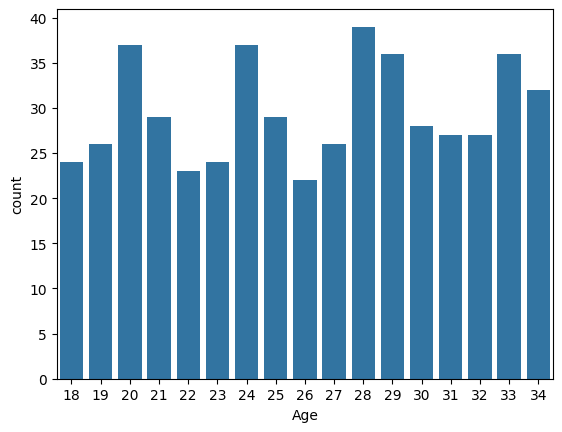

In [75]:
sns.countplot(data=df, x='Age')

In [76]:
correlacao = df.corr(numeric_only=True)

<Axes: >

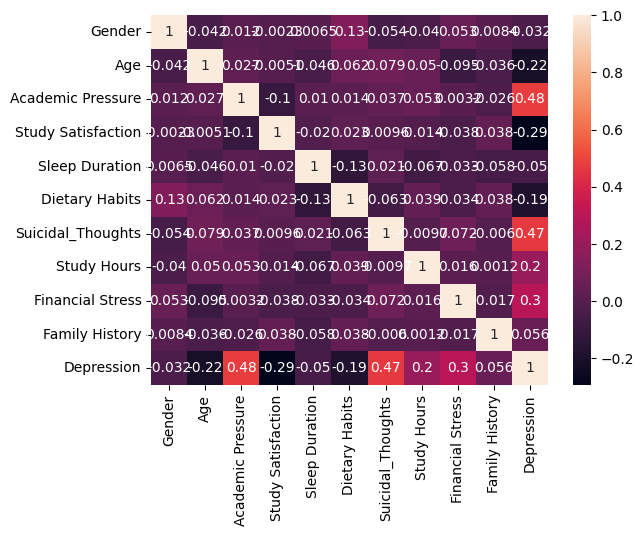

In [77]:
sns.heatmap(correlacao, annot=True)

In [78]:
df.groupby('Academic Pressure')['Depression'].mean()

,Depression
Academic Pressure,
1.0,0.171717
2.0,0.306818
3.0,0.504000
4.0,0.673913
5.0,0.846939


<Axes: xlabel='Academic Pressure', ylabel='Depression'>

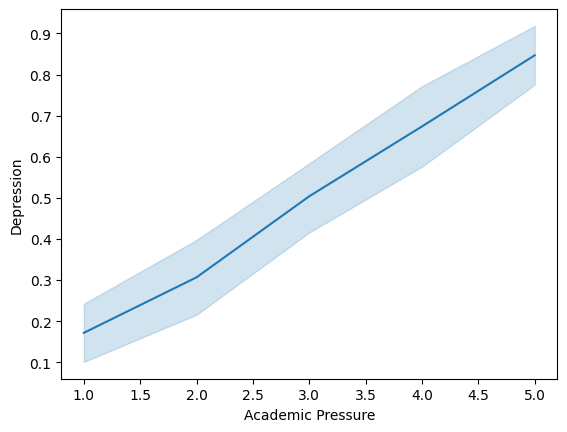

In [79]:
sns.lineplot(data=df, x='Academic Pressure', y='Depression')

In [85]:
df.groupby('Suicidal_Thoughts')['Depression'].mean()

,Depression
Suicidal_Thoughts,
0,0.260331
1,0.726923


<Axes: xlabel='Suicidal_Thoughts', ylabel='Depression'>

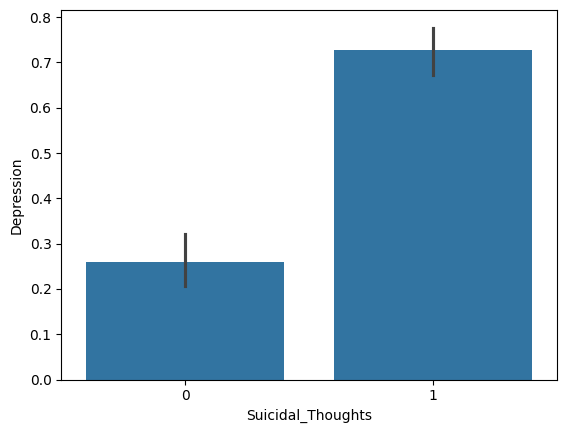

In [86]:
sns.barplot(data=df, x='Suicidal_Thoughts', y='Depression')

In [87]:
df.groupby('Financial Stress')['Depression'].mean()

,Depression
Financial Stress,
1,0.309091
2,0.382353
3,0.520000
4,0.627660
5,0.708333


<Axes: xlabel='Financial Stress', ylabel='Depression'>

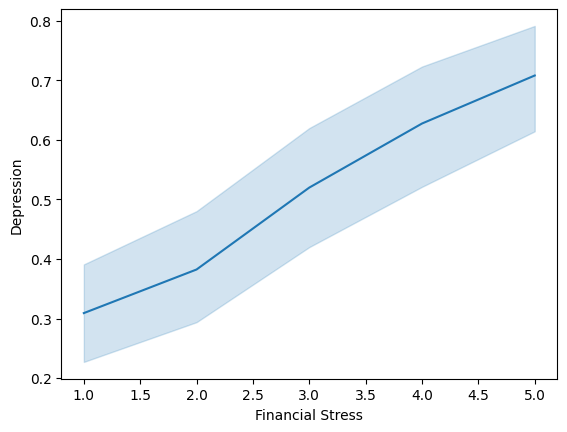

In [88]:
sns.lineplot(data=df, x='Financial Stress', y='Depression')

In [89]:
df.groupby('Study Satisfaction')['Depression'].mean()

,Depression
Study Satisfaction,
1.0,0.732558
2.0,0.620000
3.0,0.495146
4.0,0.396552
5.0,0.309278


<Axes: xlabel='Study Satisfaction', ylabel='Depression'>

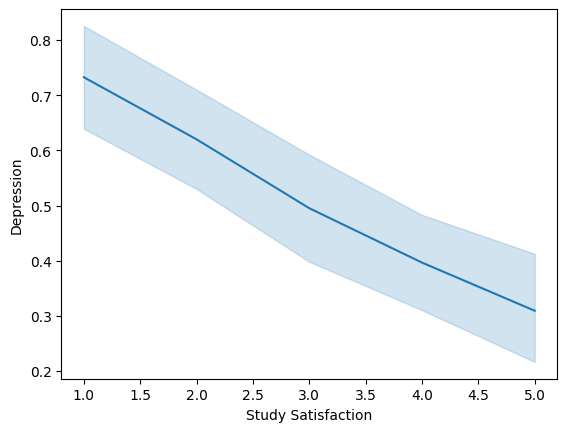

In [90]:
sns.lineplot(data=df, x='Study Satisfaction', y='Depression')

In [91]:
df.groupby('Dietary Habits')['Depression'].mean()

,Depression
Dietary Habits,
0,0.627219
1,0.476744
2,0.397516


<Axes: xlabel='Dietary Habits', ylabel='Depression'>

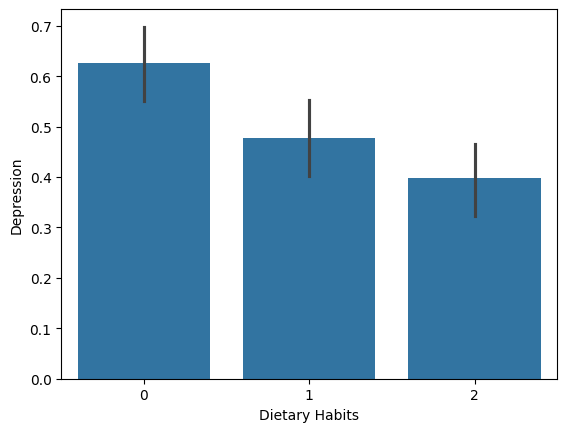

In [92]:
sns.barplot(data=df, x='Dietary Habits', y='Depression')

In [93]:
df.groupby('Age')['Depression'].mean()

,Depression
Age,
18,0.708333
19,0.615385
20,0.702703
21,0.551724
22,0.478261
23,0.541667
24,0.648649
25,0.482759
26,0.545455


<Axes: xlabel='Age', ylabel='Depression'>

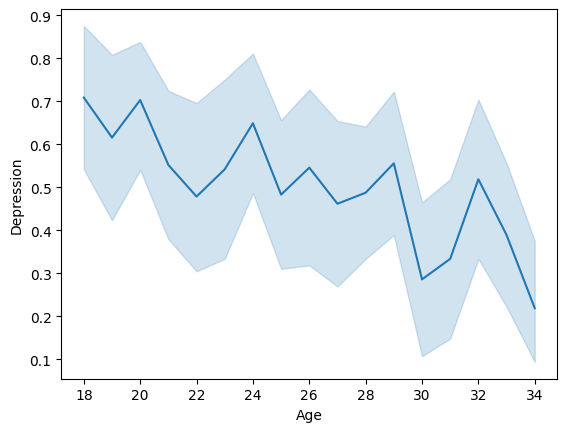

In [94]:
sns.lineplot(data=df, x='Age', y='Depression')